F = 6.50 L/h, minimum KLa = 16.40 h^-1, min CL = 0.602 mg/L
F = 7.00 L/h, minimum KLa = 16.06 h^-1, min CL = 0.604 mg/L
F = 7.50 L/h, minimum KLa = 15.81 h^-1, min CL = 0.605 mg/L
F = 8.00 L/h, minimum KLa = 15.61 h^-1, min CL = 0.605 mg/L
F = 8.50 L/h, minimum KLa = 15.41 h^-1, min CL = 0.600 mg/L
F = 9.00 L/h, minimum KLa = 15.31 h^-1, min CL = 0.603 mg/L
F = 9.50 L/h, minimum KLa = 15.21 h^-1, min CL = 0.604 mg/L
F = 10.00 L/h, minimum KLa = 15.11 h^-1, min CL = 0.604 mg/L


C:\Users\maintenant Pret\AppData\Local\Temp\ipykernel_25152\1384536812.py:91: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


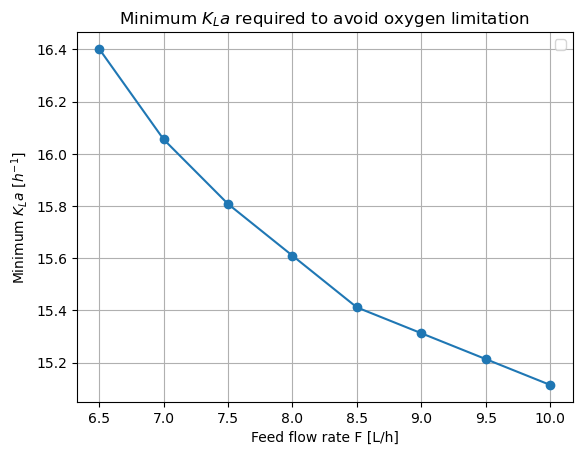

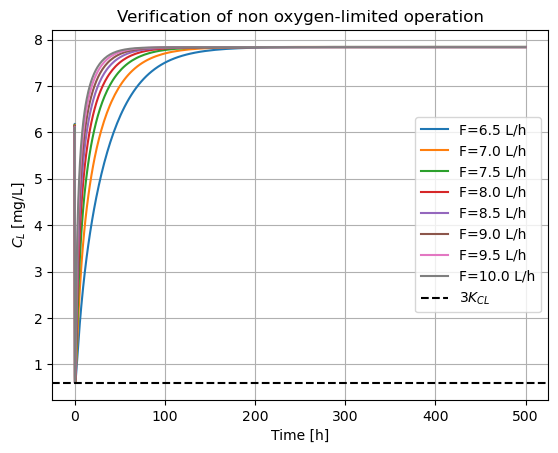

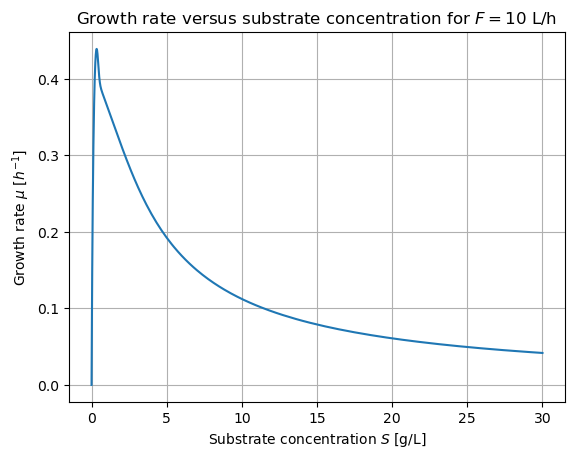

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Parameters
mu_m = 0.9        # h^-1
K_S = 0.21        # g/L
K_I = 1.5         # g/L
Y_XS = 0.6
K_CL = 0.2        # mg/L
Y_OS = 160        # mg/g

M = 0.0314
V_L = 90          # L
G = 5000          # L/h
eps = 0.2
V_G = eps * V_L

C_Li = 6          # mg/L
C_Gi = 250        # mg/L
S_i = 30          # g/L

# Initial conditions
y0 = [1, 0, 6, 250]   # X, S, C_L, C_G

# Oxygen limitation threshold
CL_limit = 3 * K_CL   # 0.6 mg/L


def growth_rate(S, CL):
    return (mu_m * S / (K_S + S + S**2 / K_I) * CL / (K_CL + CL))


def odes(t, y, F, KLa):
    X, S, CL, CG = y
    
    mu = growth_rate(S, CL)
    CL_star = M * CG
    
    dXdt = -(F / V_L) * X + mu * X
    
    dSdt = (F / V_L) * (S_i - S) - (1 / Y_XS) * mu * X
    
    dCLdt = ((F / V_L) * (C_Li - CL) - (Y_OS / Y_XS) * mu * X + KLa * (CL_star - CL))
    
    dCGdt = ((G / V_G) * (C_Gi - CG) - KLa * (V_L / V_G) * (CL_star - CL))
    
    return [dXdt, dSdt, dCLdt, dCGdt]


def simulate(F, KLa, t_end=500):
    sol = solve_ivp(odes, [0, t_end], y0, args=(F, KLa), method="BDF", rtol=1e-6, atol=1e-6)
    return sol


def minimum_CL(F, KLa):
    sol = simulate(F, KLa)
    CL = sol.y[2]
    return np.min(CL), sol


# Feed flow rates
F_values = np.linspace(6.5, 10, 8)

KLa_values = []
solutions = {}

for F in F_values:
    for KLa in np.linspace(1, 100, 2000):
        CL_min, sol = minimum_CL(F, KLa)
        
        if CL_min > CL_limit:
            KLa_values.append(KLa)
            solutions[F] = sol
            
            print(
                f"F = {F:.2f} L/h, "
                f"minimum KLa = {KLa:.2f} h^-1, "
                f"min CL = {CL_min:.3f} mg/L"
            )
            break


# Plot KLa versus F
plt.figure()
plt.plot(F_values, KLa_values, marker="o")
plt.xlabel("Feed flow rate F [L/h]")
plt.ylabel(r"Minimum $K_La$ [$h^{-1}$]")
plt.title(r"Minimum $K_La$ required to avoid oxygen limitation")
plt.grid(True)
plt.legend()
plt.show()


# Plot CL over time for verification
plt.figure()

for F, KLa in zip(F_values, KLa_values):
    sol = solutions[F]
    plt.plot(sol.t, sol.y[2], label=f"F={F:.1f} L/h")

plt.axhline(CL_limit, color="black", linestyle="--", label=r"$3K_{CL}$")
plt.xlabel("Time [h]")
plt.ylabel(r"$C_L$ [mg/L]")
plt.title(r"Verification of non oxygen-limited operation")
plt.grid(True)
plt.legend()
plt.show()


# Growth rate versus substrate concentration for F = 10 L/h
F_target = 10
KLa_target = KLa_values[-1]
sol = solutions[F_target]

S = sol.y[1]
CL = sol.y[2]
mu = growth_rate(S, CL)

idx = np.argsort(S)

plt.figure()
plt.plot(S[idx], mu[idx])
plt.xlabel(r"Substrate concentration $S$ [g/L]")
plt.ylabel(r"Growth rate $\mu$ [$h^{-1}$]")
plt.title(r"Growth rate versus substrate concentration for $F=10$ L/h")
plt.grid(True)
plt.show()